# LGBM & XGBM

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=150
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,StackingClassifier,BaggingClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



!pip install xgboost
from xgboost import XGBClassifier
%matplotlib inline

# Exploratory Data Analysis (EDA):

In [105]:
train=pd.read_csv("Titanic_train.csv")
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [37]:
train.shape

(891, 12)

In [159]:
train.drop(columns=['PassengerId','Name','Ticket'],inplace=True) #It does not provide much information

In [160]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [161]:
train.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

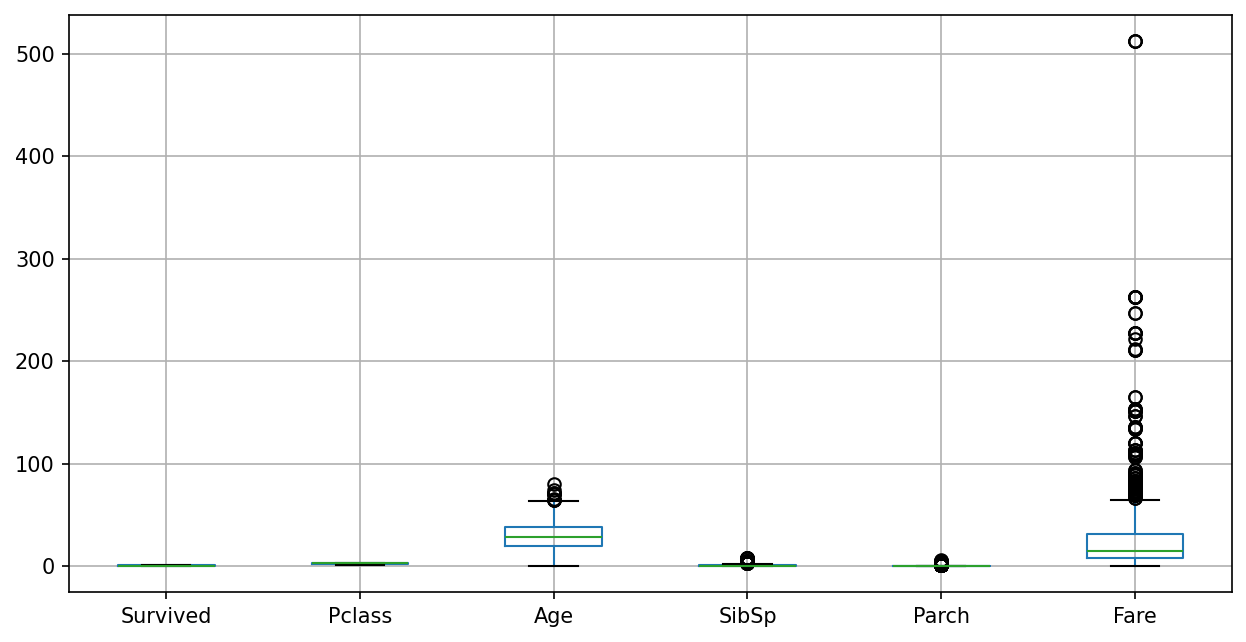

In [162]:
train.boxplot()
plt.show()

In [163]:
train['Age'].fillna(train['Age'].median(),inplace=True)

In [164]:
train['Embarked'].fillna(train['Embarked'].mode()[0],inplace=True)

In [165]:
for i in train.isna().sum():
    print((i/len(train))*100)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
77.10437710437711
0.0


In [166]:
#large number of missing values are there so the varible is not carring much informaton so I droped the varible
train.drop(columns=['Cabin'],inplace=True)

In [167]:
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [168]:
# Here I see the statastical information about the numerical columns
train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [169]:
train.describe(include=object)

,Sex,Embarked
count,891,891
unique,2,3
top,male,S
freq,577,646


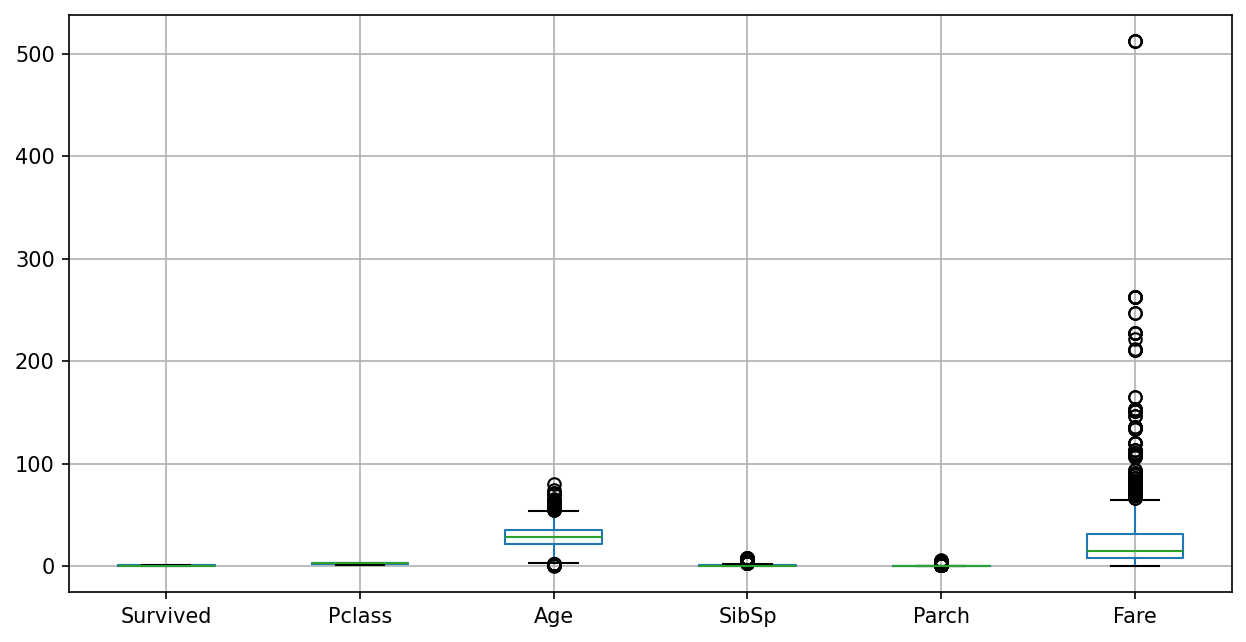

In [170]:
train.boxplot()
plt.show()

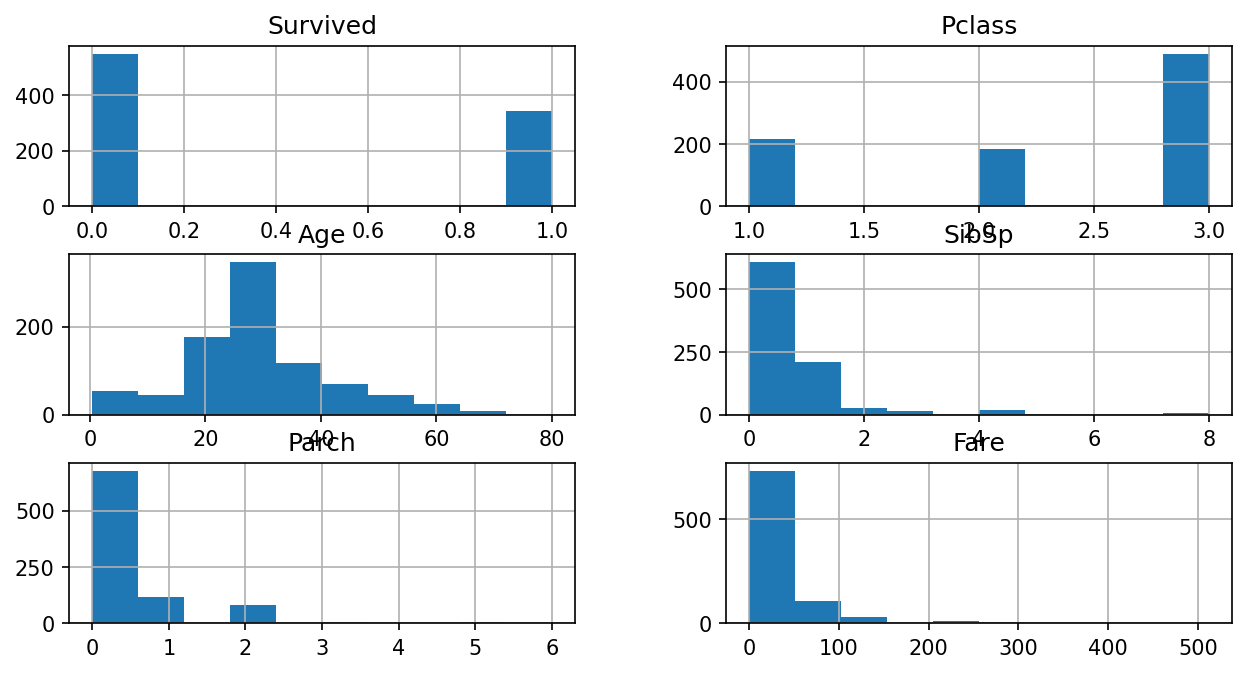

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [171]:
# with the help of histogram I see the distribution of the data
train.hist()
plt.show()
plt.tight_layout

In [172]:
def capping(data, columns):
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3-q1
    
        lower = q1-(1.5*iqr)
        upper = q3+(1.5*iqr)
        
        data[col] = np.where(data[col] > upper, upper, np.where(data[col] < lower, lower,data[col]))

In [173]:
#with the help of user defined function I remove the outliers
capping(train,['Age','SibSp','Parch','Fare'])

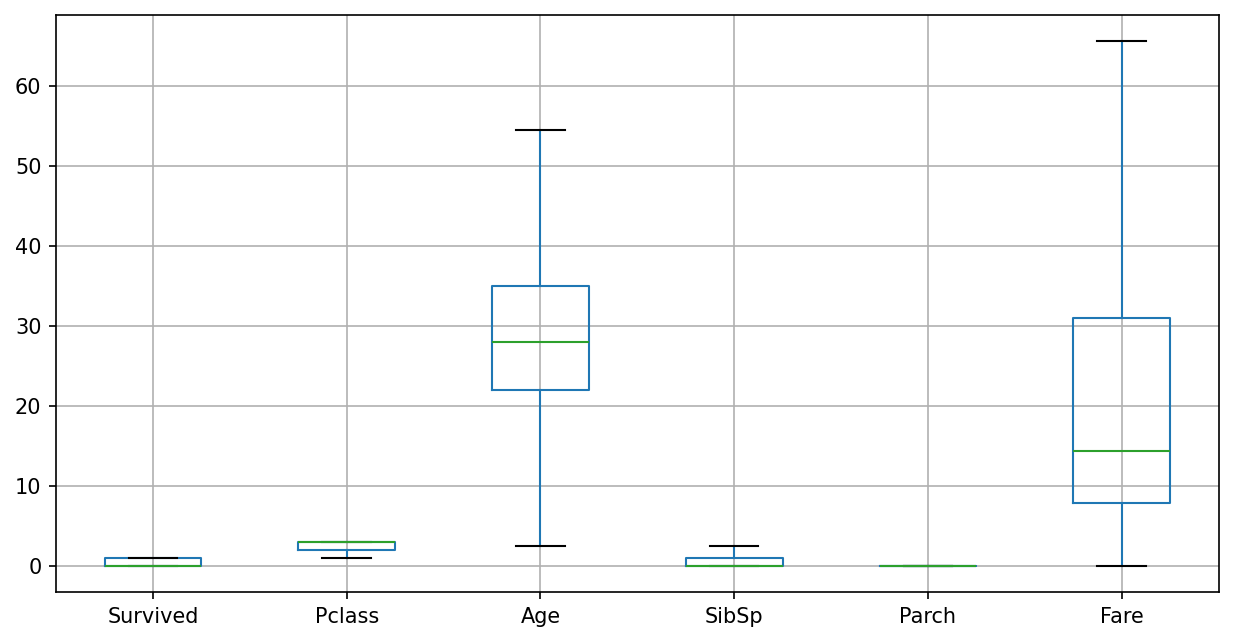

In [174]:
train.boxplot()
plt.show()

In [175]:
#Here I see the relationship betwwn the variables and also seen the which are the variables are important for predicting the target variable.
train.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.060622,0.031434,NaN,0.317430
Pclass,-0.338481,1.000000,-0.340404,0.023180,NaN,-0.715300
Age,-0.060622,-0.340404,1.000000,-0.247806,NaN,0.144544
SibSp,0.031434,0.023180,-0.247806,1.000000,NaN,0.349615
Parch,NaN,NaN,NaN,NaN,NaN,NaN
Fare,0.317430,-0.715300,0.144544,0.349615,NaN,1.000000


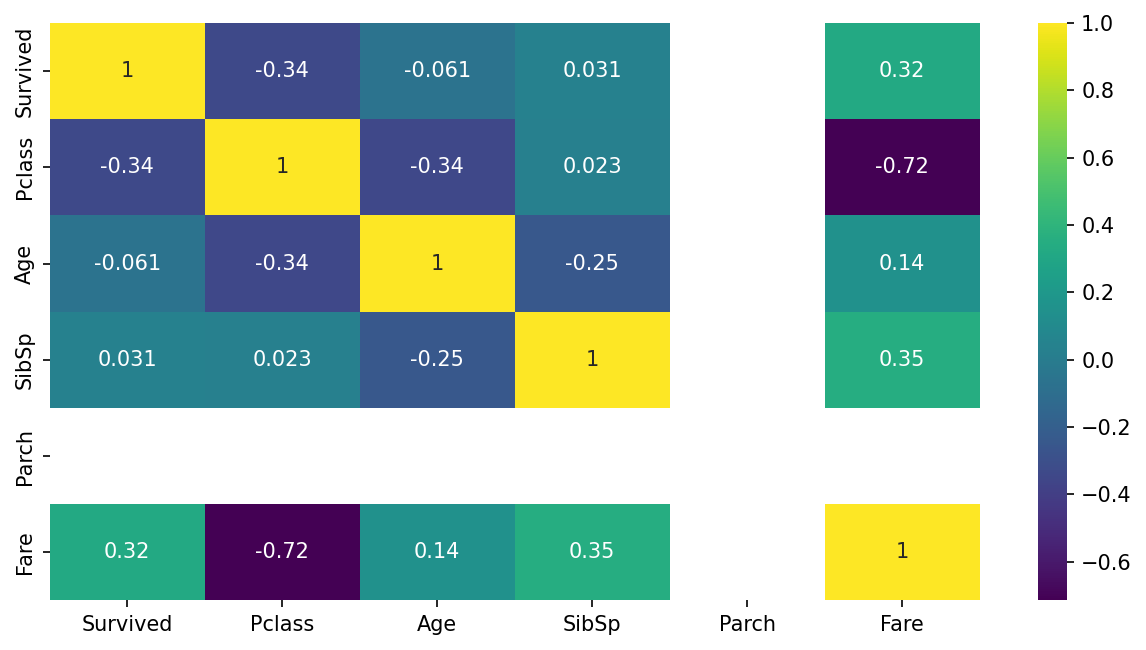

In [176]:
sns.heatmap(train.corr(numeric_only=True),annot=True,cmap='viridis')
plt.show()

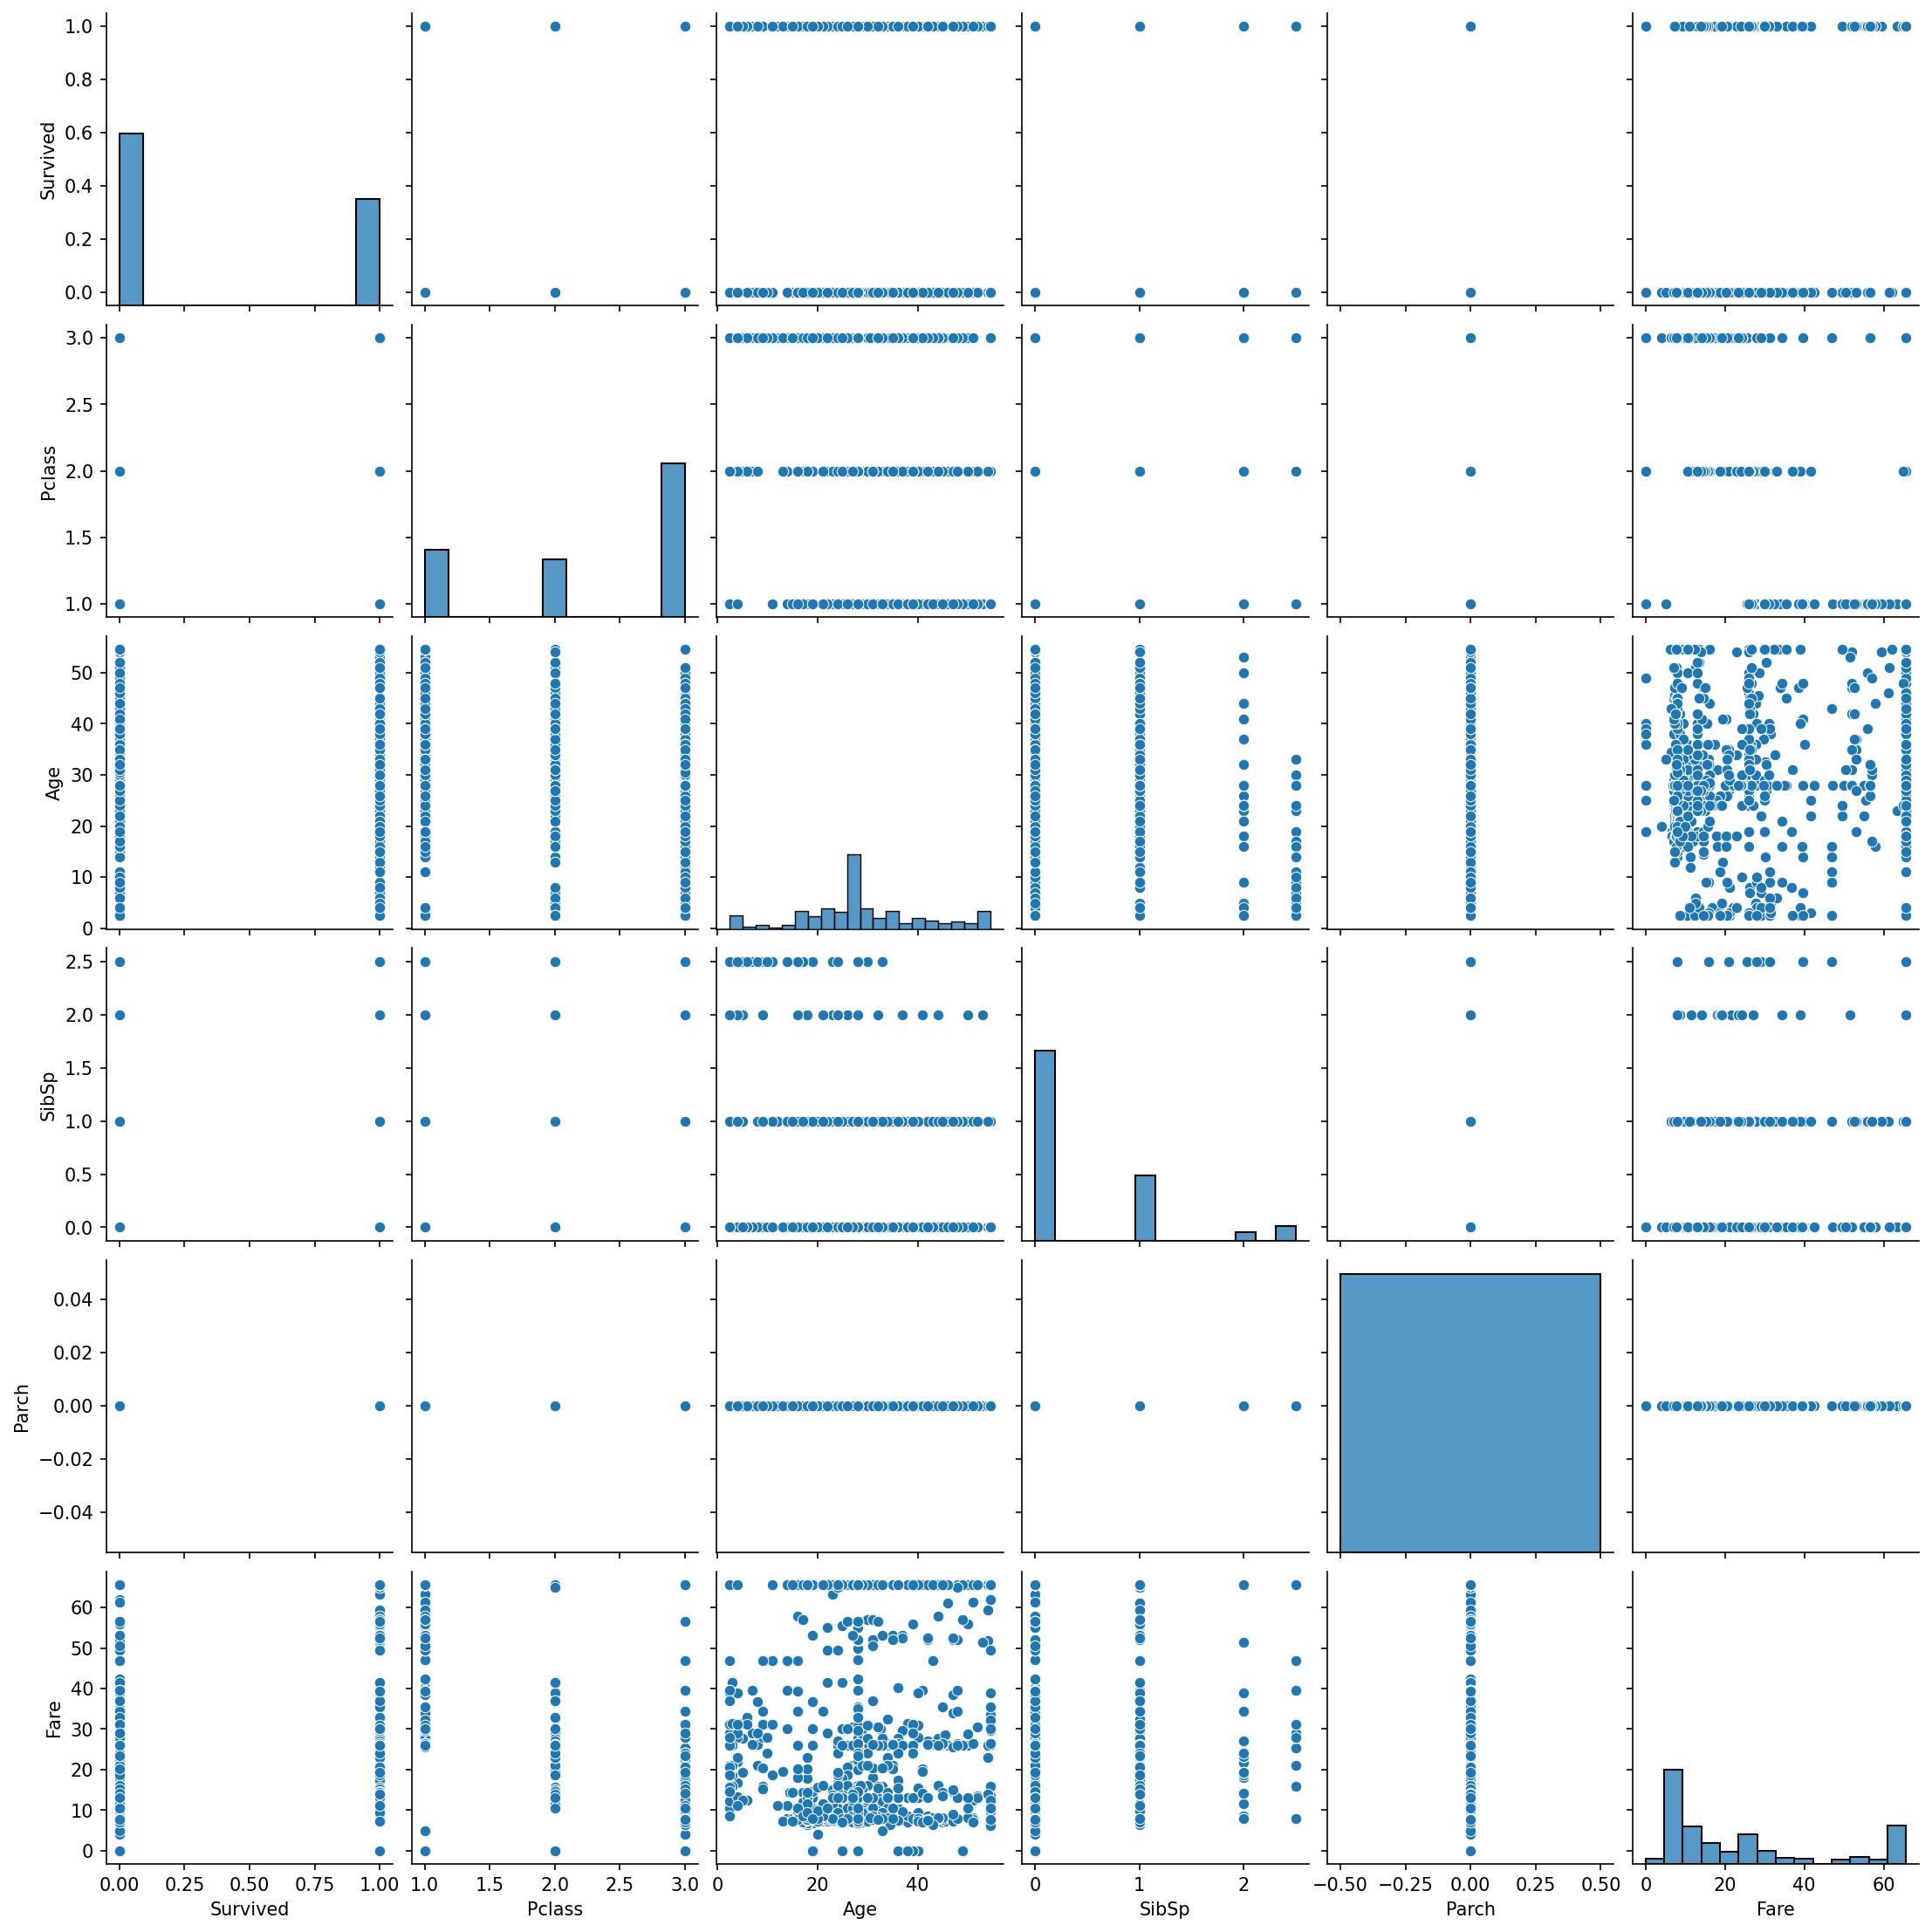

In [177]:
sns.pairplot(train)
plt.show()

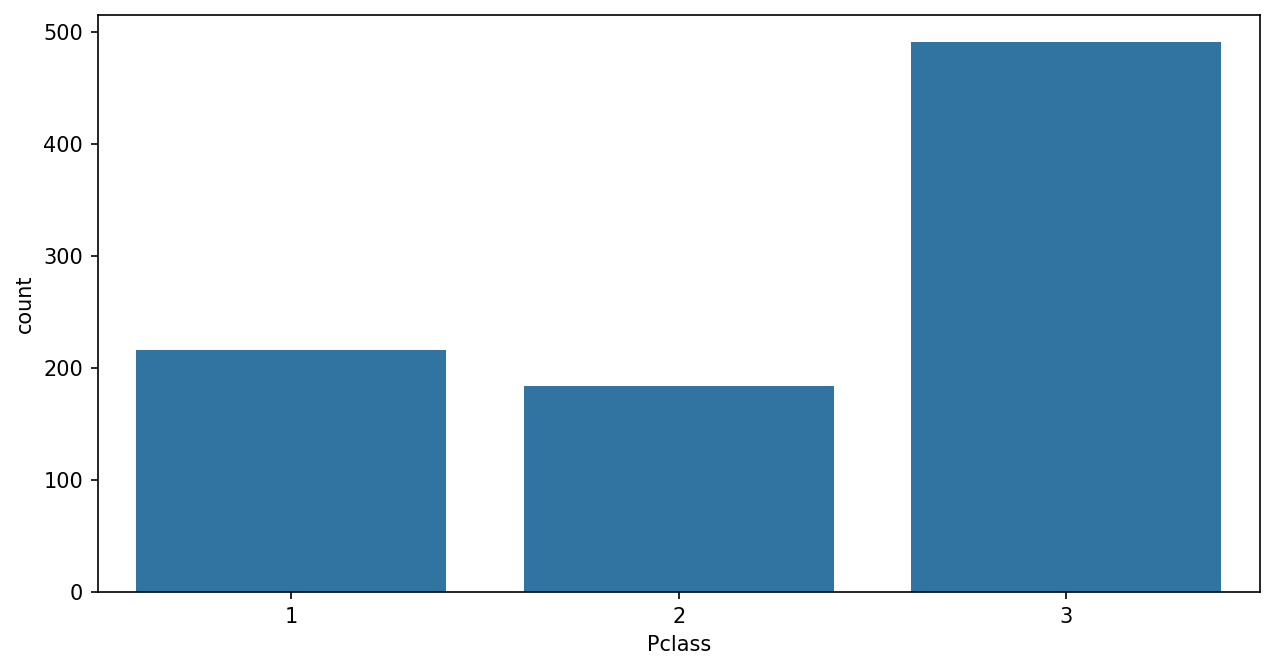

In [178]:
sns.countplot(x=train['Pclass'])
plt.show()

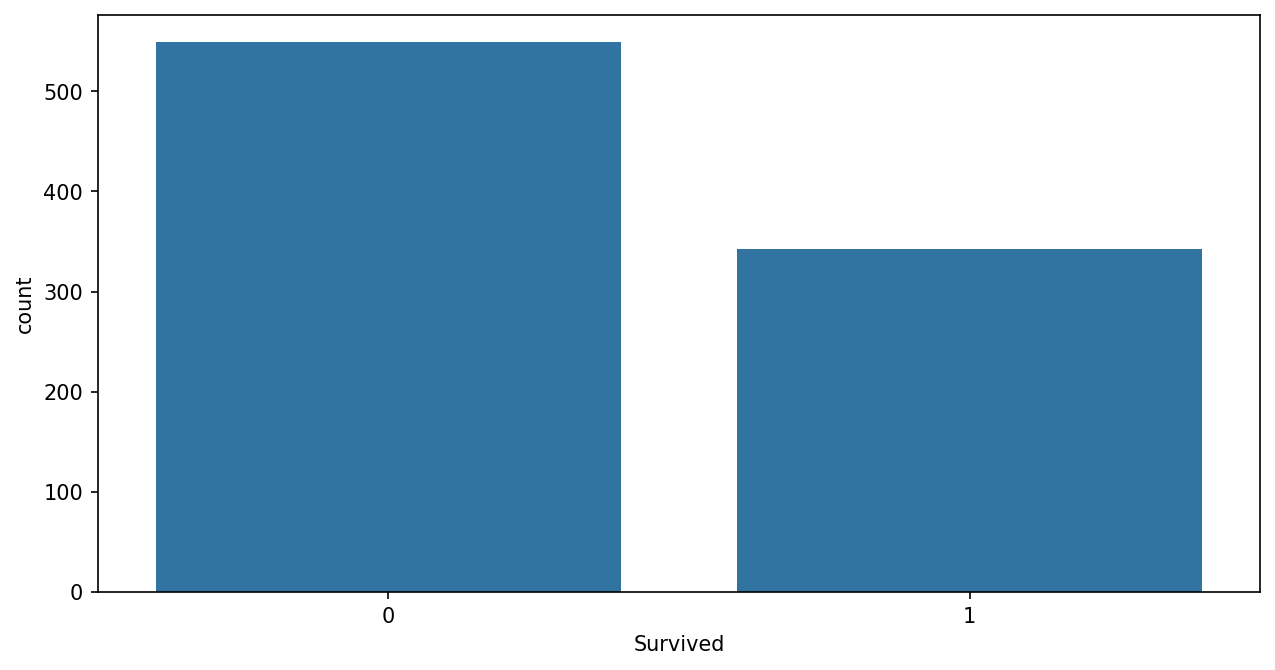

In [179]:
sns.countplot(x=train['Survived'])
plt.show()

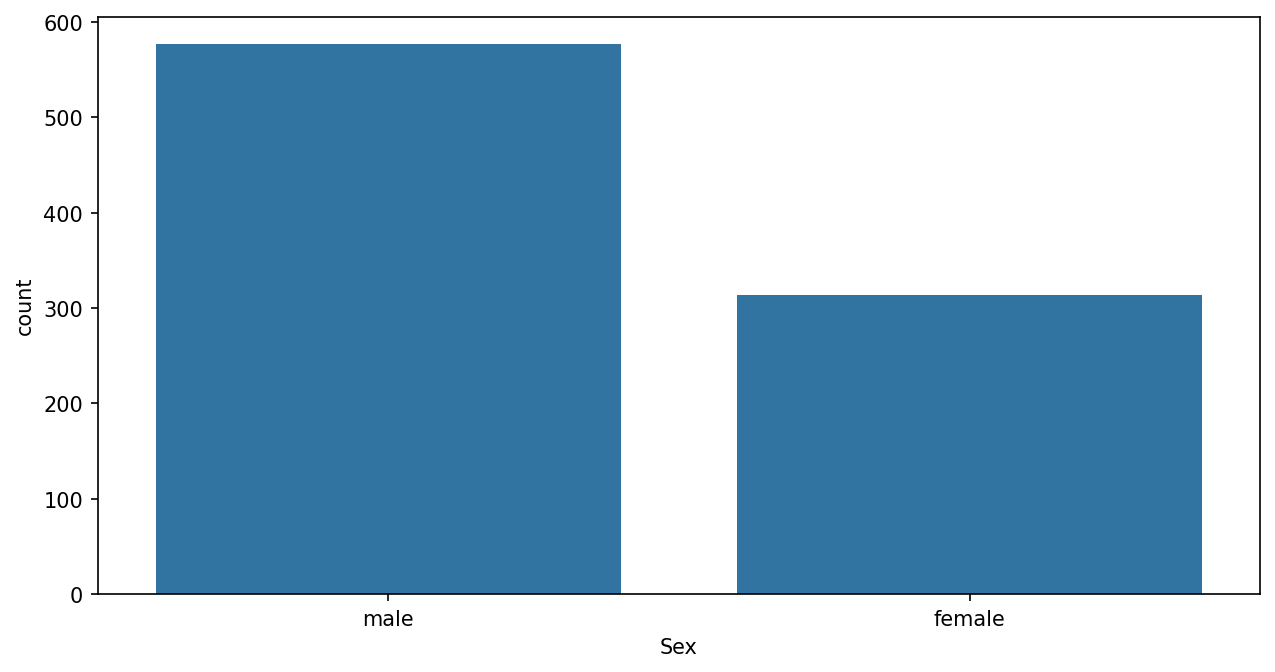

In [180]:
sns.countplot(x=train['Sex'])
plt.show()

In [64]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1.0,0.0,A/5 21171,7.2500,S
1,1,1,female,38.0,1.0,0.0,PC 17599,65.6344,C
2,1,3,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1.0,0.0,113803,53.1000,S
4,0,3,male,35.0,0.0,0.0,373450,8.0500,S


In [181]:
#selected the categorical column
obj=['Sex','Embarked']

In [182]:
train[obj]

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
...,...,...
886,male,S
887,female,S
888,female,S
889,male,C


In [183]:
#Here I converted the categorical variables into numerical varibles by applying ordinal encoding,it doesn't create dummy variables
oe=OrdinalEncoder()
train[obj]=oe.fit_transform(train[obj])



In [184]:
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1.0,22.0,1.0,0.0,7.2500,2.0
1,1,1,0.0,38.0,1.0,0.0,65.6344,0.0
2,1,3,0.0,26.0,0.0,0.0,7.9250,2.0
3,1,1,0.0,35.0,1.0,0.0,53.1000,2.0
4,0,3,1.0,35.0,0.0,0.0,8.0500,2.0
...,...,...,...,...,...,...,...,...
886,0,2,1.0,27.0,0.0,0.0,13.0000,2.0
887,1,1,0.0,19.0,0.0,0.0,30.0000,2.0
888,0,3,0.0,28.0,1.0,0.0,23.4500,2.0
889,1,1,1.0,26.0,0.0,0.0,30.0000,0.0


In [185]:
# Here we are separated the independent variables and dependent variables
x=train.iloc[:,1:]
y=train['Survived']

In [186]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1.0,22.0,1.0,0.0,7.2500,2.0
1,1,0.0,38.0,1.0,0.0,65.6344,0.0
2,3,0.0,26.0,0.0,0.0,7.9250,2.0
3,1,0.0,35.0,1.0,0.0,53.1000,2.0
4,3,1.0,35.0,0.0,0.0,8.0500,2.0
...,...,...,...,...,...,...,...
886,2,1.0,27.0,0.0,0.0,13.0000,2.0
887,1,0.0,19.0,0.0,0.0,30.0000,2.0
888,3,0.0,28.0,1.0,0.0,23.4500,2.0
889,1,1.0,26.0,0.0,0.0,30.0000,0.0


In [187]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [190]:
#here we split the data into training and testing set 
# spliting the dataset create 4 dataframes
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [191]:
xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,1.0,45.5,0.0,0.0,28.5000,2.0
733,2,1.0,23.0,0.0,0.0,13.0000,2.0
382,3,1.0,32.0,0.0,0.0,7.9250,2.0
704,3,1.0,26.0,1.0,0.0,7.8542,2.0
813,3,0.0,6.0,2.5,0.0,31.2750,2.0
...,...,...,...,...,...,...,...
106,3,0.0,21.0,0.0,0.0,7.6500,2.0
270,1,1.0,28.0,0.0,0.0,31.0000,2.0
860,3,1.0,41.0,2.0,0.0,14.1083,2.0
435,1,0.0,14.0,1.0,0.0,65.6344,2.0


In [192]:
ytrain

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [193]:
#Here we created the user defined fuction to build multiple models by reducing the code
def prediction(model):
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)

    print(f"Train Accuracy: {model.score(xtrain,ytrain)}")
    print(f"Test Accuracy: {model.score(xtest,ytest)}")
    print(classification_report(ytest,ypred))

# GBM

In [194]:
prediction(GradientBoostingClassifier())

Train Accuracy: 0.9030898876404494
Test Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [252]:
paramss = {
    'n_estimators' : [50,70,80,90,110], # randomly select no. of trees/models
    'learning_rate' : [0.3,0.4,0.5,0.6,0.7,0.9,1], # alpha between 0 to 1
    'max_depth' : [3,5,6,7,11]
}

In [253]:
# first we take the default parameters that time model will overfitted so to reduce overfitting we hypertune the parameters 
grid = GridSearchCV(GradientBoostingClassifier(),param_grid=paramss,verbose=1)
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 175 candidates, totalling 875 fits


GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1],
                         'max_depth': [3, 5, 6, 7, 11],
                         'n_estimators': [50, 70, 80, 90, 110]},
             verbose=1)

In [254]:
grid.best_params_

{'learning_rate': 0.4, 'max_depth': 3, 'n_estimators': 50}

In [255]:
prediction(GradientBoostingClassifier(learning_rate=0.4,max_depth=3,n_estimators=50))

Train Accuracy: 0.9382022471910112
Test Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [333]:
modelss=[]
modelss.append(('lg',LogisticRegression()))
modelss.append(('dt',DecisionTreeClassifier()))#default criterion='gini'
modelss.append(('dt1',DecisionTreeClassifier(criterion='entropy')))

In [334]:
modelss

[('lg', LogisticRegression()),
 ('dt', DecisionTreeClassifier()),
 ('dt1', DecisionTreeClassifier(criterion='entropy'))]

In [340]:
prediction(StackingClassifier(estimators=modelss,final_estimator=RandomForestClassifier(max_depth=5)))

Train Accuracy: 0.8693820224719101
Test Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# XGBM

In [212]:
prediction(XGBClassifier())

Train Accuracy: 0.9550561797752809
Test Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [242]:
params = {
    'n_estimators' : [50,60,70,80,90,100], # randomly select no. of trees/models
    'learning_rate' : [0.3,0.5,0.7,1], # alpha between 0 to 1
    'lambda': [3,4,5,6,7],
    'max_depth' : [3,4,5,6]
}

In [243]:
# first we take the default parameters that time model will overfitted so to reduce overfitting we hypertune the parameters 
grid=GridSearchCV(XGBClassifier(),param_grid=params,verbose=1)
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_b...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'lambda': [3, 4, 5, 6, 7],
                         'learning_rate': [0.3, 0.5, 0.7, 1],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [50, 60, 70, 80, 90, 100]},
             verbose=1)

In [244]:
grid.best_params_

{'lambda': 3, 'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 70}

In [230]:
prediction(XGBClassifier(reg_lambda=3,learning_rate=0.5,max_depth=3,n_estimators=70))

Train Accuracy: 0.9044943820224719
Test Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Stacking

In [259]:
models=[]
models.append(('lg',LogisticRegression()))
models.append(('dt',DecisionTreeClassifier()))#default criterion='gini'
models.append(('dt1',DecisionTreeClassifier(criterion='entropy')))

In [260]:
models

[('lg', LogisticRegression()),
 ('dt', DecisionTreeClassifier()),
 ('dt1', DecisionTreeClassifier(criterion='entropy'))]

In [261]:
prediction(StackingClassifier(estimators=models,final_estimator=RandomForestClassifier(max_depth=5)))

Train Accuracy: 0.8679775280898876
Test Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



# comparison

In [278]:
prediction(StackingClassifier(estimators=models,final_estimator=RandomForestClassifier(max_depth=5)))

Train Accuracy: 0.8581460674157303
Test Accuracy: 0.8379888268156425
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [287]:
prediction(StackingClassifier(estimators=models,final_estimator=RandomForestClassifier(max_depth=5)))

Train Accuracy: 0.8637640449438202
Test Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.84      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [291]:
test=pd.read_csv("Titanic_test.csv")
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [292]:
test.shape

(418, 11)

In [293]:
test.drop(columns=['PassengerId','Name','Ticket'],inplace=True) # we are droping this columns because this columns are not important for predicting the survived variable

In [294]:
test.dtypes

Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [295]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Cabin     91 non-null     object 
 7   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 26.3+ KB


In [296]:
test.isna().sum()

Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Fare          1
Cabin       327
Embarked      0
dtype: int64

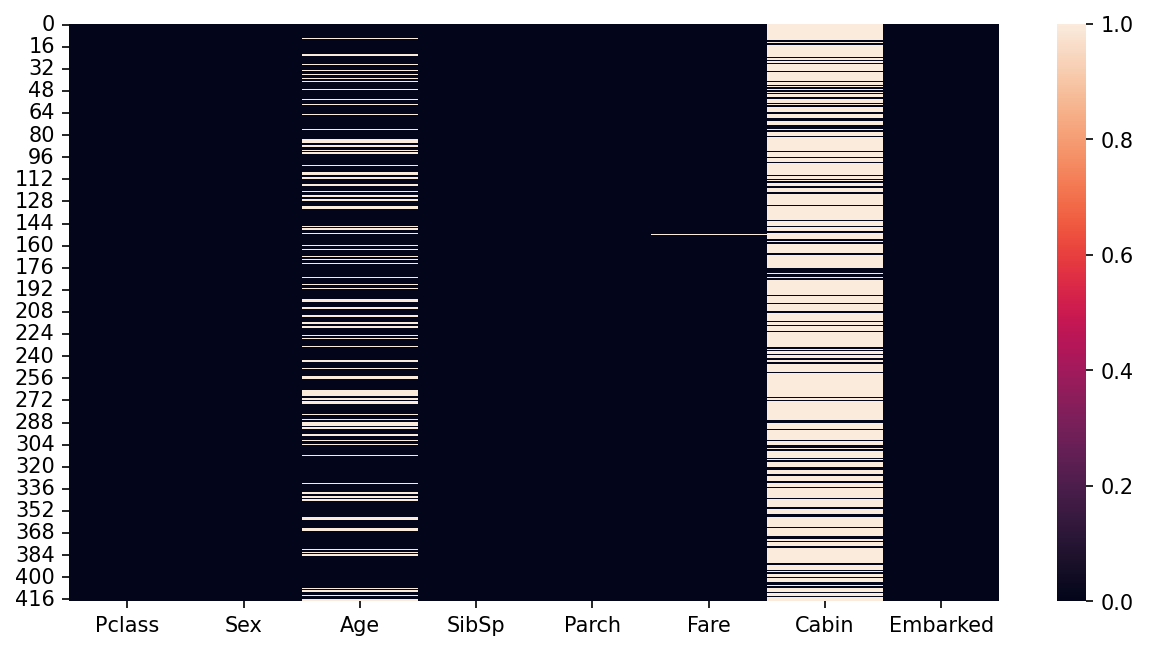

In [297]:
sns.heatmap(test.isna())
plt.show()

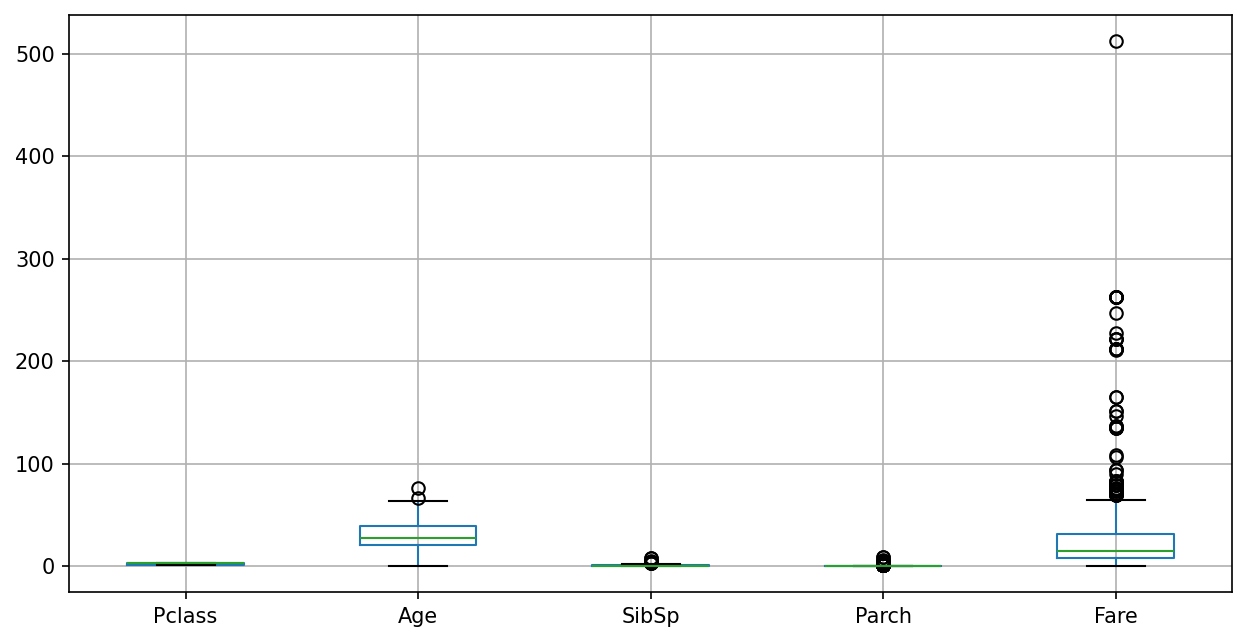

In [298]:
test.boxplot()
plt.show()

In [299]:
test['Age'].fillna(test['Age'].median(),inplace=True)

In [300]:
test.drop(columns=['Cabin'],inplace=True)

In [301]:
test['Fare'].fillna(test['Fare'].median(),inplace=True)

In [302]:
test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [303]:
test.describe()

,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000
mean,2.265550,29.599282,0.447368,0.392344,35.576535
std,0.841838,12.703770,0.896760,0.981429,55.850103
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,23.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,35.750000,1.000000,0.000000,31.471875
max,3.000000,76.000000,8.000000,9.000000,512.329200


In [304]:
test.describe(include=object)

,Sex,Embarked
count,418,418
unique,2,3
top,male,S
freq,266,270


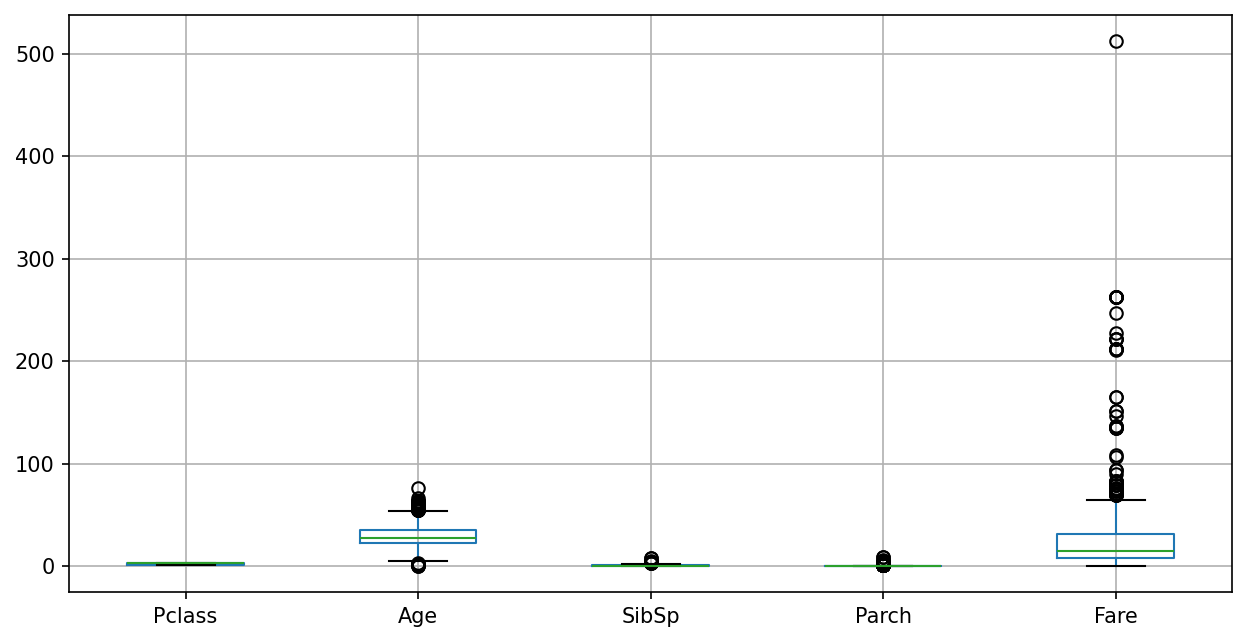

In [305]:
test.boxplot()
plt.show()

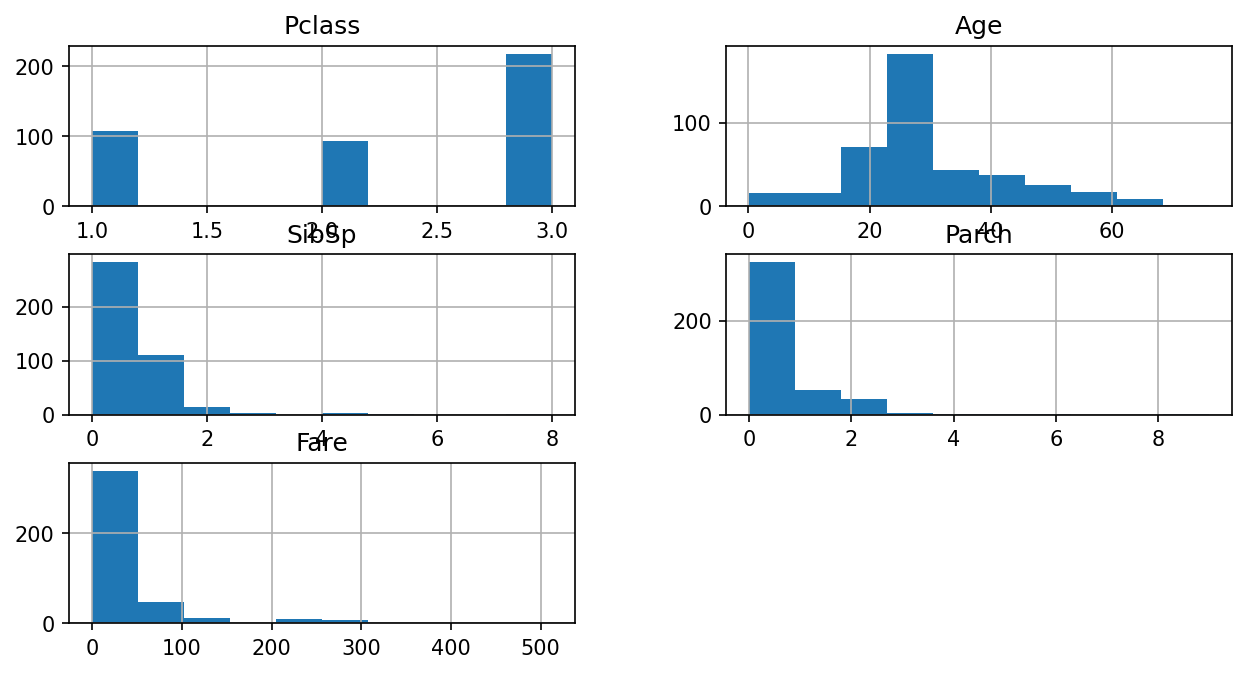

In [306]:
test.hist()
plt.show()

In [307]:
def capping(data, columns):
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3-q1
    
        lower = q1-(1.5*iqr)
        upper = q3+(1.5*iqr)
        
        data[col] = np.where(data[col] > upper, upper, np.where(data[col] < lower, lower,data[col]))

In [308]:
capping(test,['Age','SibSp','Parch','Fare'])

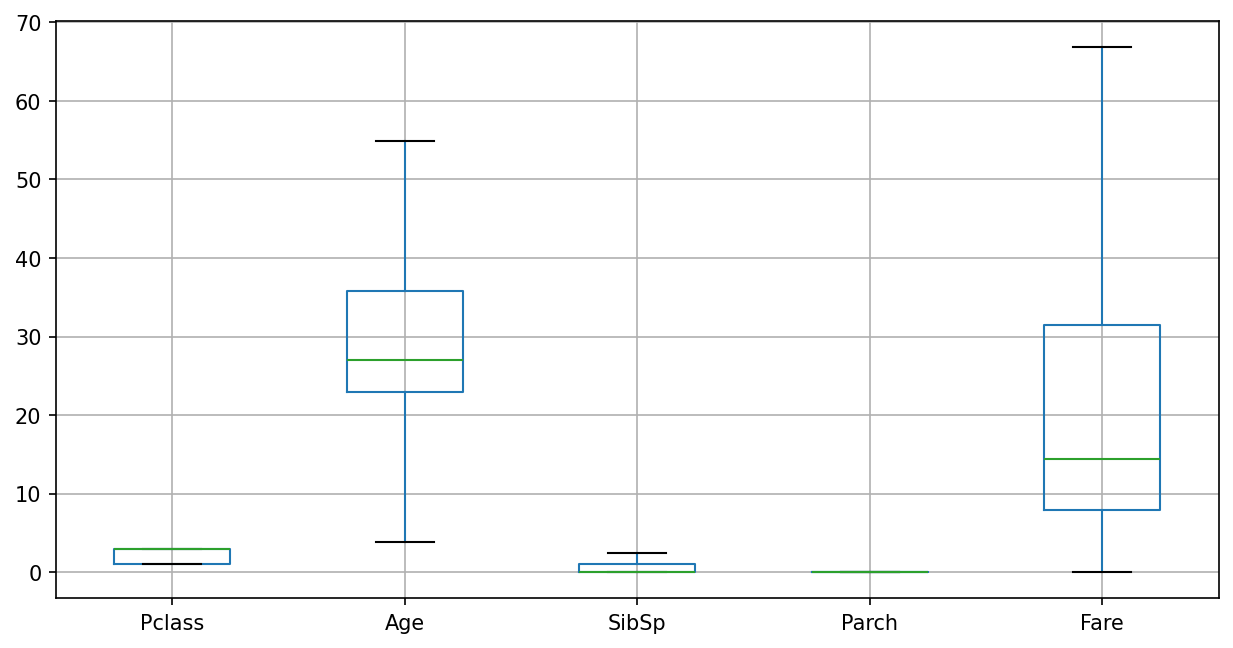

In [309]:
test.boxplot()
plt.show()

In [310]:
test.corr(numeric_only=True)

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.470951,-0.064610,NaN,-0.748755
Age,-0.470951,1.000000,-0.043117,NaN,0.350319
SibSp,-0.064610,-0.043117,1.000000,NaN,0.331912
Parch,NaN,NaN,NaN,NaN,NaN
Fare,-0.748755,0.350319,0.331912,NaN,1.000000


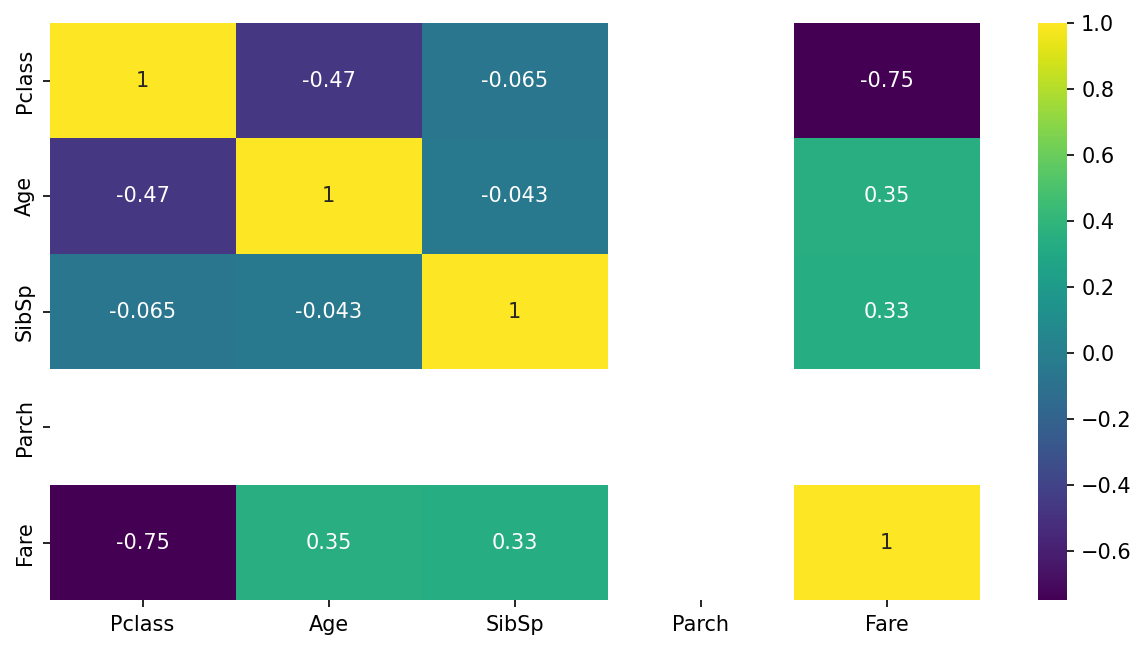

In [311]:
sns.heatmap(test.corr(numeric_only=True),annot=True,cmap='viridis')
plt.show()

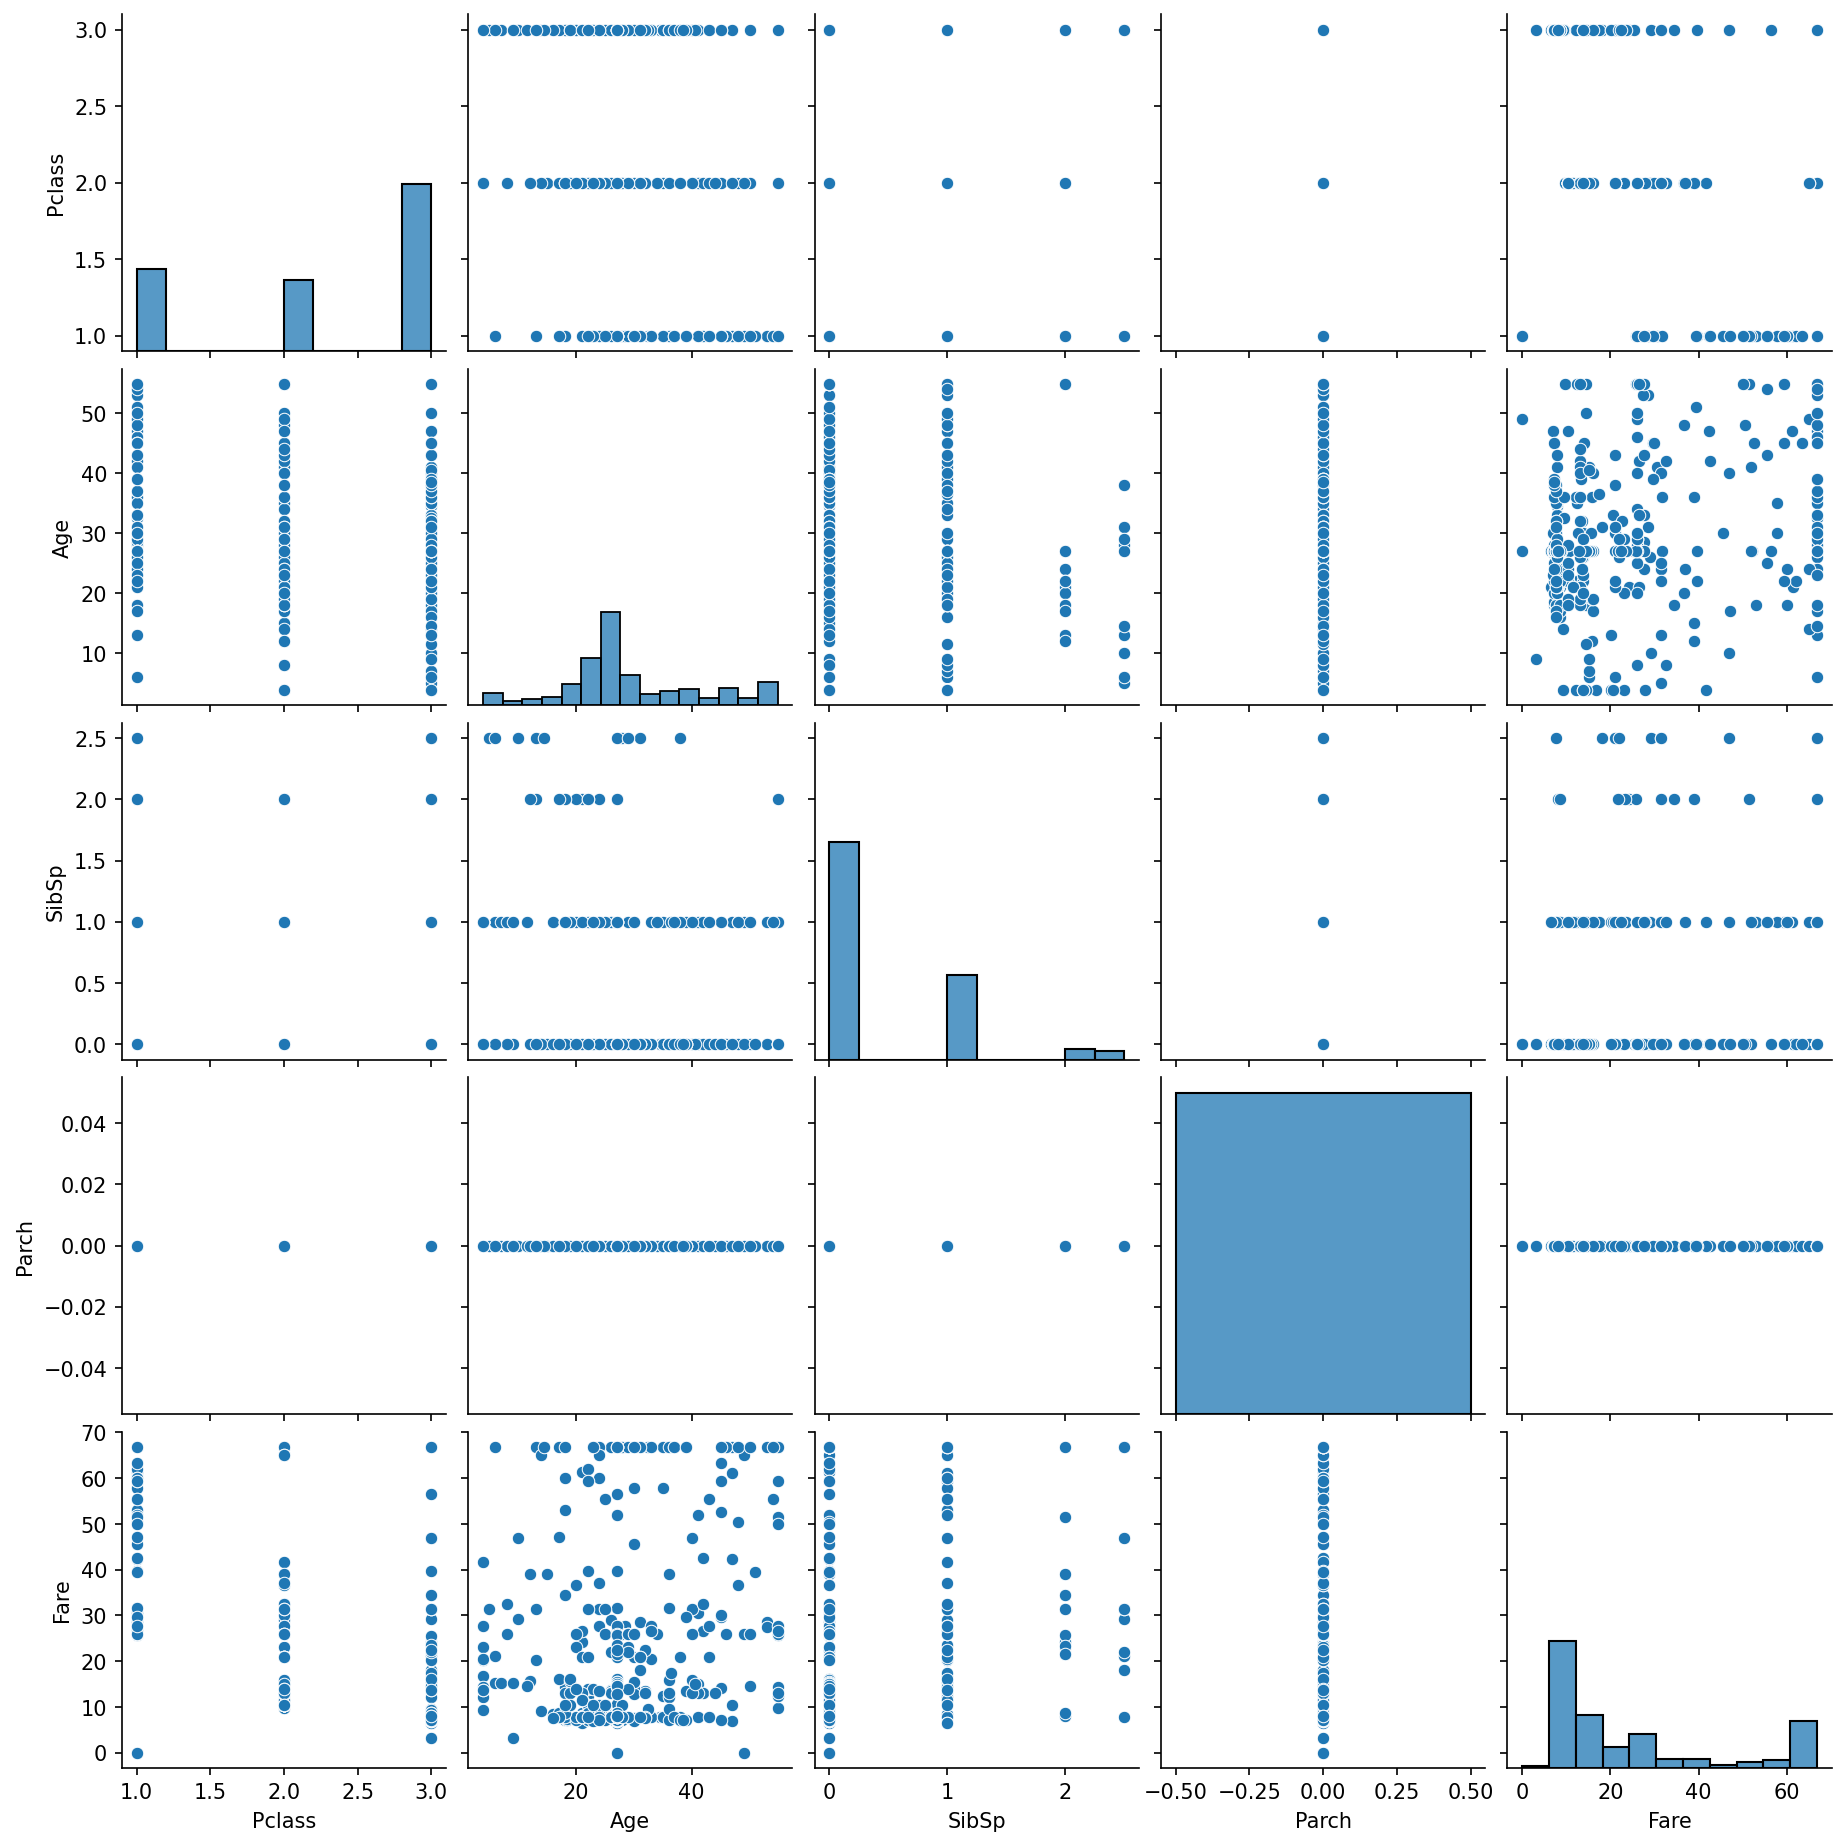

In [312]:
sns.pairplot(test)
plt.show()

In [313]:
obj1=['Sex','Embarked']

In [314]:
test[obj1]

,Sex,Embarked
0,male,Q
1,female,S
2,male,Q
3,male,S
4,female,S
...,...,...
413,male,S
414,female,C
415,male,S
416,male,S


In [315]:
test[obj1]=oe.fit_transform(test[obj])

In [316]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1.0,34.500,0.0,0.0,7.8292,1.0
1,3,0.0,47.000,1.0,0.0,7.0000,2.0
2,2,1.0,54.875,0.0,0.0,9.6875,1.0
3,3,1.0,27.000,0.0,0.0,8.6625,2.0
4,3,0.0,22.000,1.0,0.0,12.2875,2.0


# Testing on test data

In [318]:
gb=GradientBoostingClassifier(learning_rate=0.4,max_depth=3,n_estimators=50)
gb.fit(xtrain,ytrain)

GradientBoostingClassifier(learning_rate=0.4, n_estimators=50)

In [322]:
gb_pred=gb.predict(test)
gb_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,

In [326]:
print(gb.score(xtrain,ytrain))
print("Testing Accuracy:",gb.score(test,gb_pred))

0.9382022471910112
Testing Accuracy: 1.0


In [ ]:
prediction(StackingClassifier(estimators=modelss,final_estimator=RandomForestClassifier(max_depth=5)))

In [341]:
s_gb=StackingClassifier(estimators=modelss,final_estimator=RandomForestClassifier(max_depth=5))
s_gb.fit(xtrain,ytrain)

StackingClassifier(estimators=[('lg', LogisticRegression()),
                               ('dt', DecisionTreeClassifier()),
                               ('dt1',
                                DecisionTreeClassifier(criterion='entropy'))],
                   final_estimator=RandomForestClassifier(max_depth=5))

In [345]:
s_gb_pred=s_gb.predict(test)

In [346]:
print("Training Accuracy:",s_gb.score(xtrain,ytrain))
print("Testing Accuracy:",s_gb.score(test,s_gb_pred))


Training Accuracy: 0.8623595505617978
Testing Accuracy: 1.0


# 

In [330]:
xgb=XGBClassifier(reg_lambda=3,learning_rate=0.5,max_depth=3,n_estimators=70)
xgb.fit(xtrain,ytrain)
xgb_pred=xgb.predict(test)
xgb_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,

In [331]:
print(xgb.score(xtrain,ytrain))
print("Testing Accuracy:",xgb.score(test,xgb_pred))

0.9044943820224719
Testing Accuracy: 1.0


In [ ]:
prediction(StackingClassifier(estimators=models,final_estimator=RandomForestClassifier(max_depth=5)))


In [348]:
s_xgb=StackingClassifier(estimators=models,final_estimator=RandomForestClassifier(max_depth=5))
s_xgb.fit(xtrain,ytrain)

StackingClassifier(estimators=[('lg', LogisticRegression()),
                               ('dt', DecisionTreeClassifier()),
                               ('dt1',
                                DecisionTreeClassifier(criterion='entropy'))],
                   final_estimator=RandomForestClassifier(max_depth=5))

In [349]:
s_xgb_pred=s_xgb.predict(test)


In [350]:
print("Training Accuracy:",s_xgb.score(xtrain,ytrain))
print("Testing Accuracy:",s_xgb.score(test,s_xgb_pred))

Training Accuracy: 0.8820224719101124
Testing Accuracy: 1.0
